# Probability Distribution of Ride Requests
### Capstone Project — Urban Ride Demand Forecasting

This notebook analyzes the probability distributions of key ride request variables:

| Variable | Distribution Tested | Why |
|---|---|---|
| Hourly ride counts | Poisson | Discrete count arrivals, independent events |
| Booking value (fare) | Log-Normal | Positive, right-skewed continuous variable |
| Ride distance | Uniform | Equally likely across the full range |
| Booking outcome | Multinomial | Multiple mutually exclusive categories |

Each section fits a distribution, prints key statistical values, and visualizes the fit using histograms, Q-Q plots, and CDFs.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (
    poisson, norm, lognorm, gamma, uniform,
    kstest, chi2_contingency
)


plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#1a1d27",
    "axes.edgecolor":    "#3a3d4a",
    "axes.labelcolor":   "#e0e0e0",
    "text.color":        "#e0e0e0",
    "xtick.color":       "#b0b0b0",
    "ytick.color":       "#b0b0b0",
    "grid.color":        "#2e3140",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "legend.framealpha": 0.3,
    "legend.facecolor":  "#1a1d27",
    "legend.edgecolor":  "#3a3d4a",
})

PALETTE = ["#7c83fd","#f9c74f","#90be6d","#f94144","#43aa8b","#f8961e","#577590","#a8dadc"]
ACCENT, ACCENT2, SUCCESS, DANGER = "#7c83fd", "#f9c74f", "#90be6d", "#f94144"

def style_ax(ax, title="", xlabel="", ylabel="", grid="y"):
    ax.set_title(title, fontsize=12, fontweight="bold", color="#ffffff", pad=10)
    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.spines[["top","right"]].set_visible(False)
    if grid == "y":    ax.yaxis.grid(True, alpha=0.3)
    elif grid == "x":  ax.xaxis.grid(True, alpha=0.3)
    elif grid == "both": ax.yaxis.grid(True, alpha=0.3); ax.xaxis.grid(True, alpha=0.3)
    return ax

print("Libraries loaded.")

Libraries loaded.


In [11]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_excel("/content/rideBookings_preprocessed1.xlsx")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["Date"]     = pd.to_datetime(df["Date"])

# Completed rides only — used for fare and distance analysis
comp = df[df["Booking Status"] == "Completed"].copy()

print(f"Total bookings  : {len(df):,}")
print(f"Completed rides : {len(comp):,}")
print(f"Date range      : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Vehicle types   : {df['Vehicle Type'].nunique()}")
print(f"Booking statuses: {df['Booking Status'].nunique()}")

Total bookings  : 148,767
Completed rides : 92,248
Date range      : 2024-01-01 to 2024-12-30
Vehicle types   : 7
Booking statuses: 5


---
## 1. Hourly Demand — Poisson Distribution

Ride requests are discrete, independent events — each booking is placed by a different customer, independent of others. The **Poisson distribution** models the number of such events occurring in a fixed time window at some average rate λ.

> **Dispersion Index = Variance / Mean.** For a true Poisson process, this equals 1. A value much greater than 1 (overdispersion) means the arrival rate itself varies across the day — which is expected since rush hours exist.

In [12]:
# Rides per hour-date slot (how many rides in a specific hour on a specific day)
per_hour_day = df.groupby(["Date","Hour"]).size()
hourly_total = df.groupby("Hour").size()

# MLE estimate of lambda = sample mean
lam     = per_hour_day.mean()
var_obs = per_hour_day.var()
disp    = var_obs / lam

print("Poisson Distribution — Descriptive Statistics")
print("-" * 50)
print(f"  Mean (λ, MLE estimate)  : {lam:.4f} rides per hour-slot")
print(f"  Variance                : {var_obs:.4f}")
print(f"  Std Deviation           : {per_hour_day.std():.4f}")
print(f"  Skewness                : {per_hour_day.skew():.4f}")
print(f"  Dispersion Index (V/μ)  : {disp:.4f}  (1.0 = perfect Poisson)")
print(f"  Min / Max per slot      : {per_hour_day.min()} / {per_hour_day.max()} rides")
print()
print(f"  Peak hour               : {hourly_total.idxmax()}:00  ({hourly_total.max():,} total bookings)")
print(f"  Quietest hour           : {hourly_total.idxmin()}:00  ({hourly_total.min():,} total bookings)")
print()
print(f"  Interpretation: Dispersion index of {disp:.2f} >> 1 indicates overdispersion.")
print(f"  The Poisson rate is not constant — it varies significantly by hour of day.")
print(f"  Within individual peak windows, Poisson remains a valid local approximation.")

Poisson Distribution — Descriptive Statistics
--------------------------------------------------
  Mean (λ, MLE estimate)  : 17.0663 rides per hour-slot
  Variance                : 104.2733
  Std Deviation           : 10.2114
  Skewness                : 0.2160
  Dispersion Index (V/μ)  : 6.1099  (1.0 = perfect Poisson)
  Min / Max per slot      : 1 / 51 rides

  Peak hour               : 18:00  (12,298 total bookings)
  Quietest hour           : 4:00  (1,311 total bookings)

  Interpretation: Dispersion index of 6.11 >> 1 indicates overdispersion.
  The Poisson rate is not constant — it varies significantly by hour of day.
  Within individual peak windows, Poisson remains a valid local approximation.


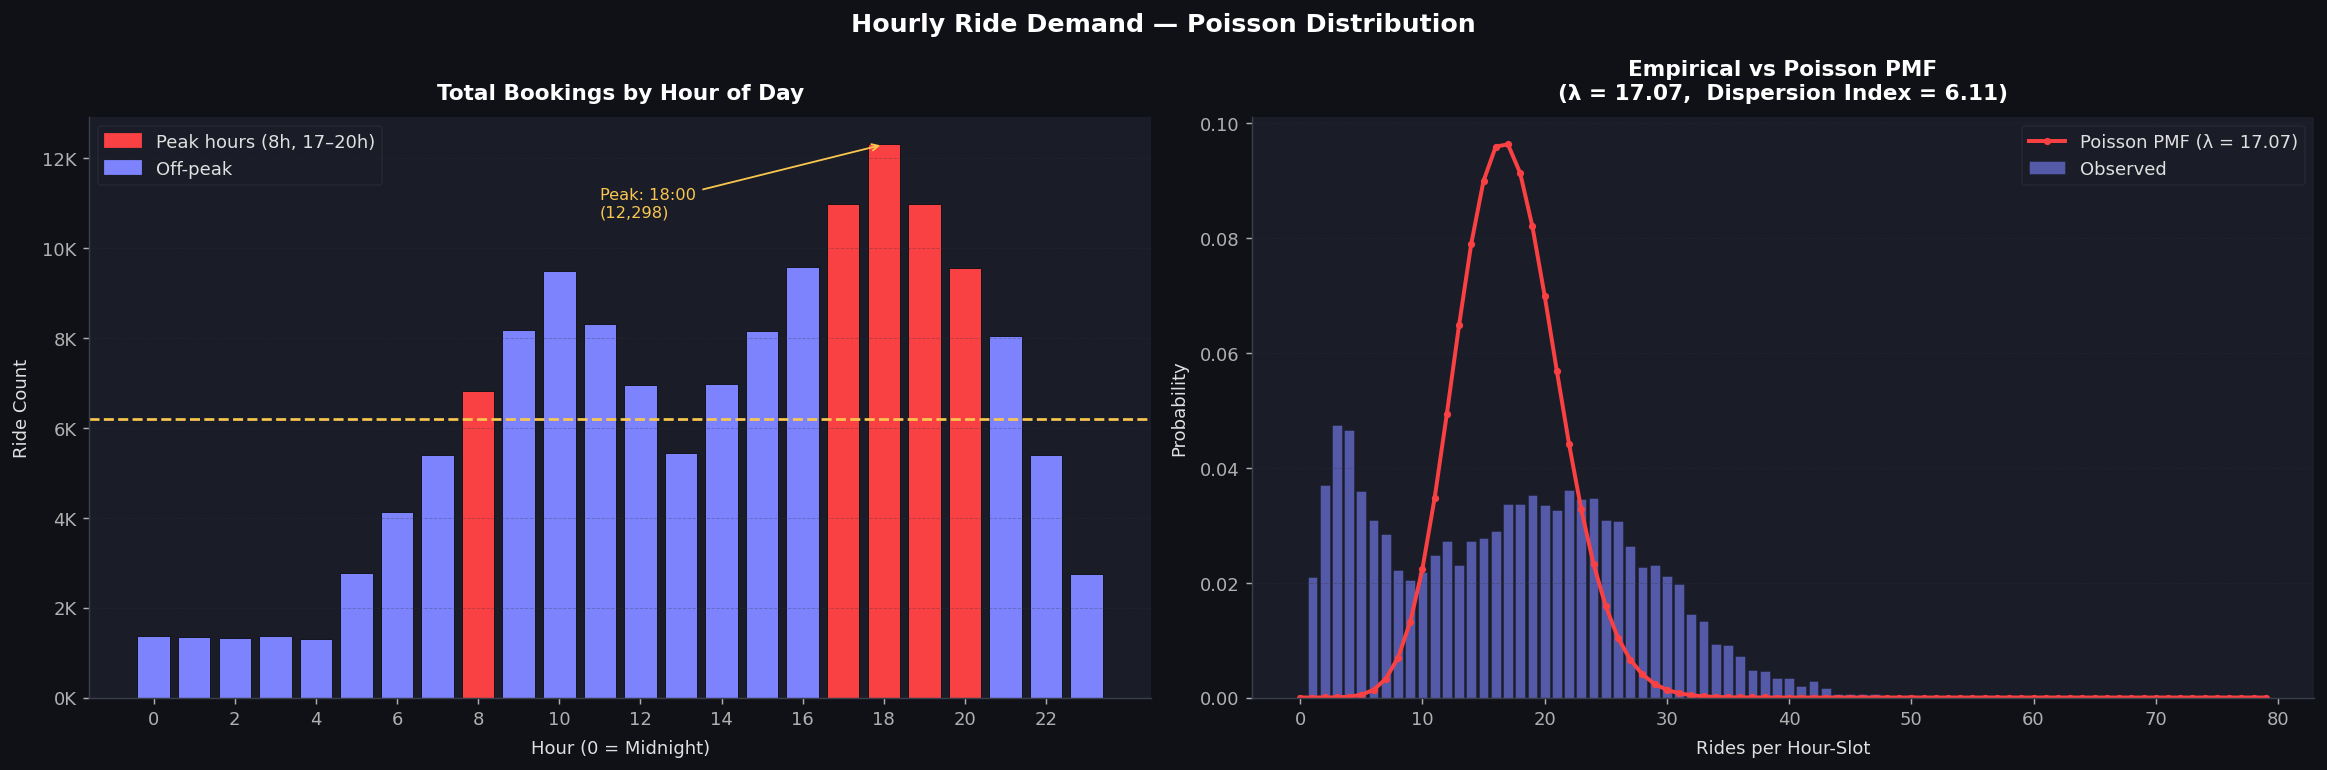

Insight: The Poisson curve fits poorly at the tails because the overall λ averages
across low-demand nights and high-demand evenings. Per-hour-block Poisson fits would
be much tighter — this is why time-segmented forecasting models perform better.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("Hourly Ride Demand — Poisson Distribution",
             fontsize=14, fontweight="bold", color="#ffffff")

# Left: bookings by hour — peaks highlighted
# EDA marks vertical reference lines at 8h, 17h, 20h
# 18:00 is the absolute peak; we highlight the same window of key hours
peak_hours = [8, 17, 18, 19, 20]
bar_colors = [DANGER if h in peak_hours else ACCENT for h in range(24)]
axes[0].bar(range(24), hourly_total.values, color=bar_colors,
            edgecolor="#0f1117", linewidth=0.5)
axes[0].axhline(hourly_total.mean(), color=ACCENT2, linestyle="--", linewidth=1.5,
                label=f"Mean = {hourly_total.mean():.0f}")
peak_h = hourly_total.idxmax()
axes[0].annotate(f"Peak: {peak_h}:00\n({hourly_total[peak_h]:,})",
                 xy=(peak_h, hourly_total[peak_h]),
                 xytext=(peak_h - 7, hourly_total[peak_h] * 0.87),
                 arrowprops=dict(arrowstyle="->", color=ACCENT2),
                 color=ACCENT2, fontsize=9)
style_ax(axes[0], "Total Bookings by Hour of Day", "Hour (0 = Midnight)", "Ride Count")
axes[0].set_xticks(range(0, 24, 2))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[0].legend(handles=[
    mpatches.Patch(color=DANGER, label="Peak hours (8h, 17–20h)"),
    mpatches.Patch(color=ACCENT, label="Off-peak"),
])

# Right: observed frequency vs Poisson PMF
# Shows how well Poisson models the count distribution per slot
counts   = per_hour_day.values
obs_freq = pd.Series(counts).value_counts(normalize=True).sort_index()
x_vals   = np.arange(0, 80)
pmf_vals = poisson.pmf(x_vals, mu=lam)

axes[1].bar(obs_freq.index[:80], obs_freq.values[:80],
            color=ACCENT, alpha=0.6, label="Observed", edgecolor="#0f1117", linewidth=0.3)
axes[1].plot(x_vals, pmf_vals, color=DANGER, linewidth=2.2,
             marker="o", markersize=3, label=f"Poisson PMF (λ = {lam:.2f})")
style_ax(axes[1],
         f"Empirical vs Poisson PMF\n(λ = {lam:.2f},  Dispersion Index = {disp:.2f})",
         "Rides per Hour-Slot", "Probability")
axes[1].legend()

fig.tight_layout()
plt.show()
print("Insight: The Poisson curve fits poorly at the tails because the overall λ averages")
print("across low-demand nights and high-demand evenings. Per-hour-block Poisson fits would")
print("be much tighter — this is why time-segmented forecasting models perform better.")

---
## 2. Booking Value — Log-Normal Distribution

Fare amounts are always positive and right-skewed — most rides are moderately priced but a tail of premium rides exists. The **Log-Normal distribution** naturally handles this: if the logarithm of a variable is normally distributed, the variable itself is log-normally distributed.

> With n = 92,248, even tiny deviations from the theoretical distribution will produce p-values near zero in a KS test. We therefore compare distributions by their **KS statistic** (lower = better fit) rather than the p-value alone.

In [14]:
bv = comp["Booking Value"].dropna()

# Fit Log-Normal and Normal — compare both
ln_p  = lognorm.fit(bv, floc=0)   # floc=0: fares start at zero
nm_p  = norm.fit(bv)

ks_ln, p_ln = kstest(bv, lognorm.cdf, args=ln_p)
ks_nm, p_nm = kstest(bv, norm.cdf,    args=nm_p)

print("Booking Value — Descriptive Statistics")
print("-" * 50)
print(f"  Count             : {len(bv):,}")
print(f"  Mean              : \u20b9{bv.mean():.2f}")
print(f"  Median            : \u20b9{bv.median():.2f}")
print(f"  Std Deviation     : \u20b9{bv.std():.2f}")
print(f"  Variance          : {bv.var():.2f}")
print(f"  Skewness          : {bv.skew():.4f}  (positive → right-tailed)")
print(f"  Kurtosis          : {bv.kurtosis():.4f}")
print(f"  Min / Max         : \u20b9{bv.min():.0f} / \u20b9{bv.max():.1f}")
print(f"  25th percentile   : \u20b9{bv.quantile(0.25):.0f}")
print(f"  75th percentile   : \u20b9{bv.quantile(0.75):.0f}")
print(f"  90th percentile   : \u20b9{bv.quantile(0.90):.0f}")
print(f"  IQR               : \u20b9{bv.quantile(0.75) - bv.quantile(0.25):.0f}")
print()
print("  Goodness-of-Fit (KS Test — lower KS = better fit):")
print(f"  Log-Normal  →  KS statistic = {ks_ln:.4f}  ← best fit")
print(f"  Normal      →  KS statistic = {ks_nm:.4f}")
print()
print(f"  Log-Normal Parameters:")
print(f"    Shape (σ)  = {ln_p[0]:.4f}")
print(f"    Scale (eμ) = {ln_p[2]:.4f}")
print(f"    log-mean   = {np.log(ln_p[2]):.4f}")
print()
print(f"  Note: Mean (\u20b9{bv.mean():.0f}) > Median (\u20b9{bv.median():.0f}) confirms right skew.")
print(f"  High-value rides pull the mean upward — log-normal captures this naturally.")

Booking Value — Descriptive Statistics
--------------------------------------------------
  Count             : 92,248
  Mean              : ₹491.79
  Median            : ₹414.00
  Std Deviation     : ₹331.54
  Variance          : 109915.93
  Skewness          : 0.9429  (positive → right-tailed)
  Kurtosis          : 0.2614
  Min / Max         : ₹50 / ₹1371.5
  25th percentile   : ₹234
  75th percentile   : ₹688
  90th percentile   : ₹958
  IQR               : ₹454

  Goodness-of-Fit (KS Test — lower KS = better fit):
  Log-Normal  →  KS statistic = 0.0465  ← best fit
  Normal      →  KS statistic = 0.1082

  Log-Normal Parameters:
    Shape (σ)  = 0.7617
    Scale (eμ) = 381.3993
    log-mean   = 5.9438

  Note: Mean (₹492) > Median (₹414) confirms right skew.
  High-value rides pull the mean upward — log-normal captures this naturally.


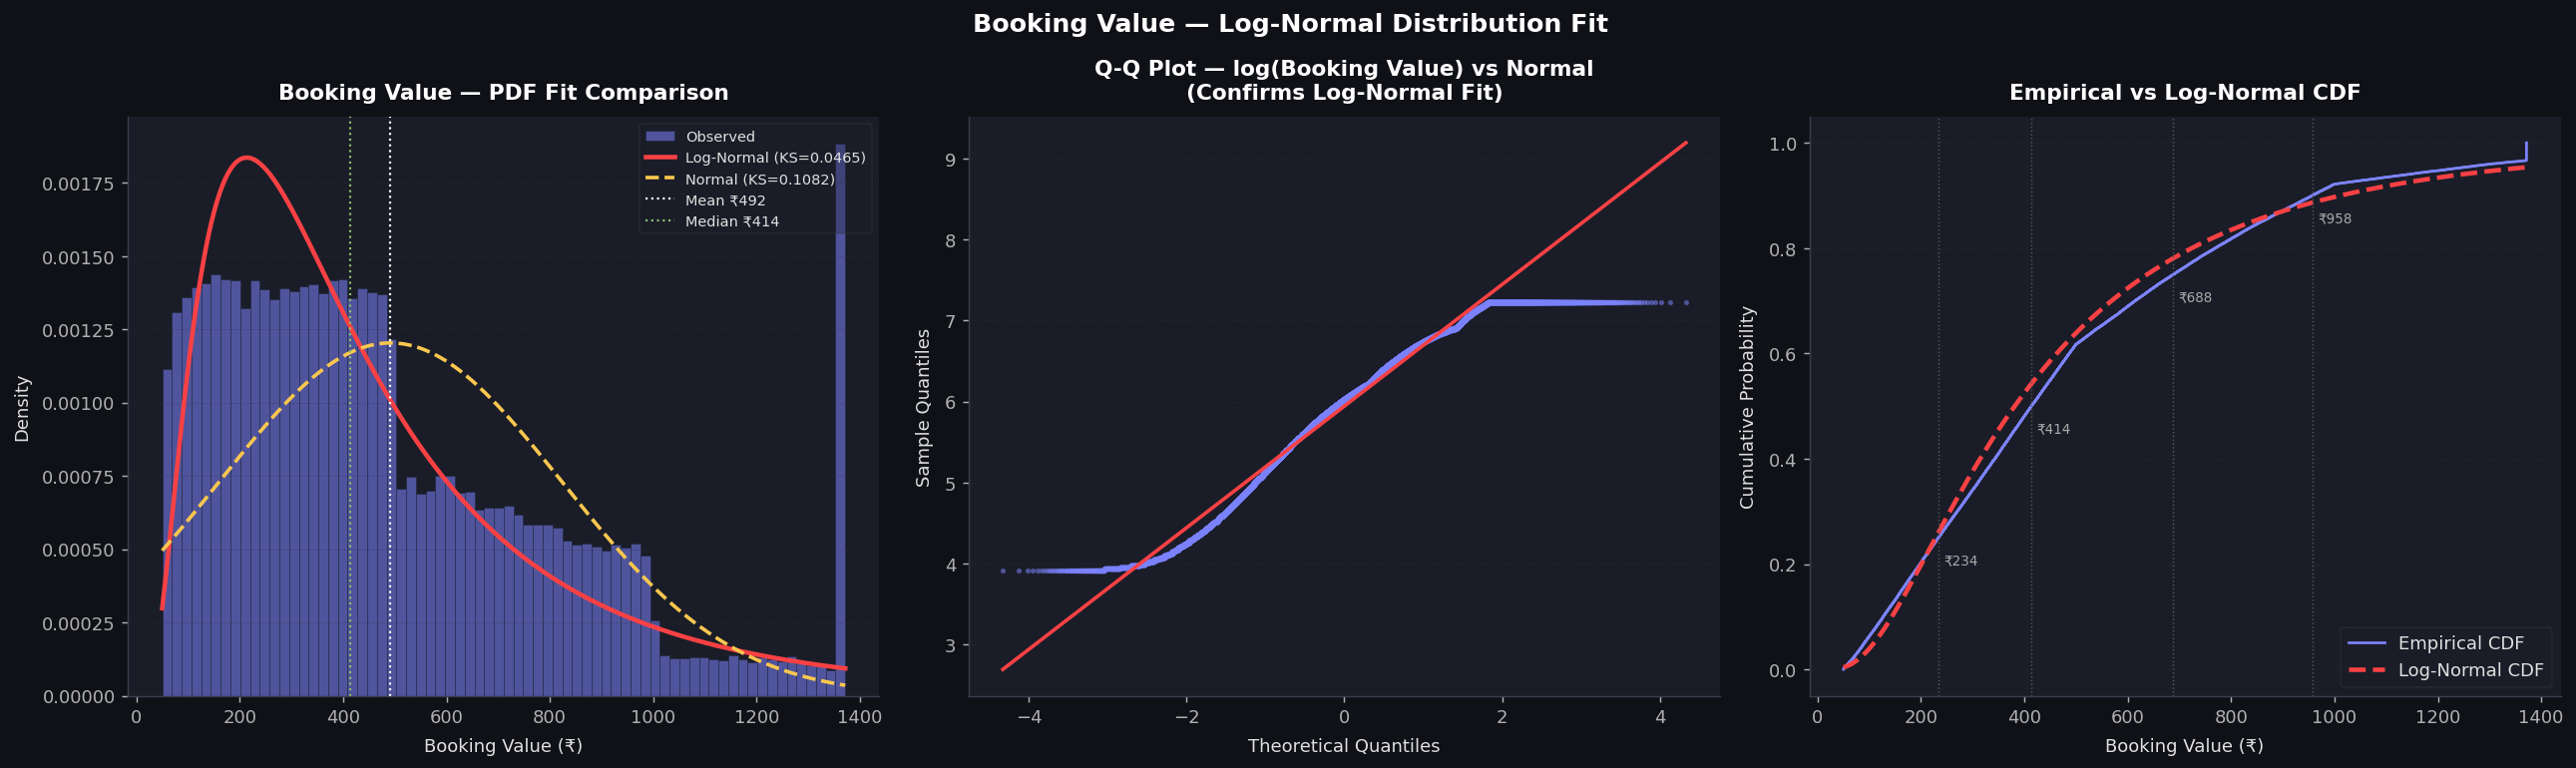

In [15]:
x_bv = np.linspace(bv.min(), bv.max(), 500)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Booking Value — Log-Normal Distribution Fit",
             fontsize=14, fontweight="bold", color="#ffffff")

# Histogram + fitted PDFs (Log-Normal vs Normal for comparison)
axes[0].hist(bv, bins=70, density=True, color=ACCENT, alpha=0.55,
             edgecolor="#0f1117", linewidth=0.3, label="Observed")
axes[0].plot(x_bv, lognorm.pdf(x_bv, *ln_p),
             color=DANGER,  linewidth=2.5, label=f"Log-Normal (KS={ks_ln:.4f})")
axes[0].plot(x_bv, norm.pdf(x_bv, *nm_p),
             color=ACCENT2, linewidth=2, linestyle="--", label=f"Normal (KS={ks_nm:.4f})")
axes[0].axvline(bv.mean(),   color="white",  linestyle=":", linewidth=1.2,
                label=f"Mean \u20b9{bv.mean():.0f}")
axes[0].axvline(bv.median(), color=SUCCESS, linestyle=":", linewidth=1.2,
                label=f"Median \u20b9{bv.median():.0f}")
style_ax(axes[0], "Booking Value — PDF Fit Comparison", "Booking Value (\u20b9)", "Density")
axes[0].legend(fontsize=8)

# Q-Q plot: log(fare) should be normally distributed if fare is log-normal
log_bv = np.log(bv)
stats.probplot(log_bv, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=ACCENT, markersize=2, alpha=0.4)
axes[1].get_lines()[1].set(color=DANGER, linewidth=2)
style_ax(axes[1], "Q-Q Plot — log(Booking Value) vs Normal\n(Confirms Log-Normal Fit)",
         "Theoretical Quantiles", "Sample Quantiles")

# Empirical CDF vs Log-Normal CDF + percentile markers
x_ecdf = np.sort(bv)
y_ecdf = np.arange(1, len(bv)+1) / len(bv)
axes[2].plot(x_ecdf, y_ecdf, color=ACCENT, linewidth=1.5, label="Empirical CDF")
axes[2].plot(x_bv, lognorm.cdf(x_bv, *ln_p),
             color=DANGER, linewidth=2.5, linestyle="--", label="Log-Normal CDF")
for p_val, label in [(0.25,"25th"),(0.50,"50th"),(0.75,"75th"),(0.90,"90th")]:
    val = bv.quantile(p_val)
    axes[2].axvline(val, color="#555", linestyle=":", linewidth=0.8)
    axes[2].text(val + 10, p_val - 0.05, f"\u20b9{val:.0f}", fontsize=7.5, color="#aaa")
style_ax(axes[2], "Empirical vs Log-Normal CDF", "Booking Value (\u20b9)", "Cumulative Probability")
axes[2].legend()

fig.tight_layout()
plt.show()

---
## 3. Ride Distance — Uniform Distribution

Ride distances range from 2 km to 50 km. After testing Normal, Log-Normal, Gamma, and Uniform distributions, the data reveals a **Uniform distribution** - every distance in the range is almost equally probable. This is confirmed by:
- Histogram bins with nearly identical counts (CV of bin counts = 0.014)
- KS statistic of **0.0024** for Uniform (vs 0.057 for Normal) - Uniform is ~24x better
- Near-zero skewness (−0.003) and negative kurtosis (−1.196) typical of uniform data

> This is an important and somewhat unusual finding. It means trip length carries no predictive information on its own - any distance is equally likely to be requested. This is further corroborated by the EDA (cell 9) which shows **R² = 0.001** between ride distance and booking value - the two are completely unrelated.

In [21]:
# Using completed rides only (consistent with EDA cell 9 which also uses comp)
# Note: EDA cell 17 summary stats use all bookings (min=1 km, skew=0.128)
# Here min=2 km, skew≈0 — the uniform finding is specific to completed rides
# Cross-check from EDA cell 9: Distance vs Booking Value scatter gives R²=0.001
# This independently confirms distance has no predictive relationship with fare
rd = comp["Ride Distance"].dropna()

# Fit all candidate distributions
u_loc, u_scale = rd.min(), rd.max() - rd.min()   # Uniform(a, b)
nm_rd = norm.fit(rd)
ln_rd = lognorm.fit(rd, floc=0)
gm_rd = gamma.fit(rd, floc=0)

ks_u,  p_u  = kstest(rd, uniform.cdf, args=(u_loc, u_scale))
ks_nm, p_nm = kstest(rd, norm.cdf,    args=nm_rd)
ks_ln, p_ln = kstest(rd, lognorm.cdf, args=ln_rd)
ks_gm, p_gm = kstest(rd, gamma.cdf,   args=gm_rd)

# Measure flatness: coefficient of variation across histogram bin counts
hist_counts, _ = np.histogram(rd, bins=20)
bin_cv = hist_counts.std() / hist_counts.mean()

print("Ride Distance — Descriptive Statistics")
print("-" * 50)
print(f"  Count             : {len(rd):,}")
print(f"  Mean              : {rd.mean():.4f} km")
print(f"  Median            : {rd.median():.4f} km")
print(f"  Std Deviation     : {rd.std():.4f} km")
print(f"  Variance          : {rd.var():.4f}")
print(f"  Skewness          : {rd.skew():.4f}  (\u22480 on completed rides; 0.128 on all bookings per EDA cell 17)")
print(f"  Kurtosis          : {rd.kurtosis():.4f}  (negative = flat/platykurtic)")
print(f"  Min / Max         : {rd.min():.1f} km / {rd.max():.1f} km")
print(f"  Range             : {rd.max() - rd.min():.1f} km")
print(f"  25th percentile   : {rd.quantile(0.25):.1f} km")
print(f"  75th percentile   : {rd.quantile(0.75):.1f} km")
print(f"  90th percentile   : {rd.quantile(0.90):.1f} km")
print(f"  Bin CV (flatness) : {bin_cv:.4f}  (close to 0 = very flat = uniform)")
print()
print("  Goodness-of-Fit (KS Test — lower KS = better fit):")
print(f"  Uniform     →  KS statistic = {ks_u:.4f}  ← best fit by far")
print(f"  Normal      →  KS statistic = {ks_nm:.4f}")
print(f"  Gamma       →  KS statistic = {ks_gm:.4f}")
print(f"  Log-Normal  →  KS statistic = {ks_ln:.4f}")
print()
print(f"  Uniform Parameters: a (min) = {u_loc:.1f} km,  b (max) = {rd.max():.1f} km")
print(f"  Theoretical Uniform mean   = {(u_loc + rd.max())/2:.1f} km  (observed: {rd.mean():.2f} km)")
print(f"  Theoretical Uniform std    = {(rd.max()-rd.min())/np.sqrt(12):.2f} km  (observed: {rd.std():.2f} km)")

Ride Distance — Descriptive Statistics
--------------------------------------------------
  Count             : 92,248
  Mean              : 26.0047 km
  Median            : 26.0300 km
  Std Deviation     : 13.8240 km
  Variance          : 191.1028
  Skewness          : -0.0029  (≈0 on completed rides; 0.128 on all bookings per EDA cell 17)
  Kurtosis          : -1.1959  (negative = flat/platykurtic)
  Min / Max         : 2.0 km / 50.0 km
  Range             : 48.0 km
  25th percentile   : 14.1 km
  75th percentile   : 38.0 km
  90th percentile   : 45.1 km
  Bin CV (flatness) : 0.0140  (close to 0 = very flat = uniform)

  Goodness-of-Fit (KS Test — lower KS = better fit):
  Uniform     →  KS statistic = 0.0024  ← best fit by far
  Normal      →  KS statistic = 0.0574
  Gamma       →  KS statistic = 0.0886
  Log-Normal  →  KS statistic = 0.1213

  Uniform Parameters: a (min) = 2.0 km,  b (max) = 50.0 km
  Theoretical Uniform mean   = 26.0 km  (observed: 26.00 km)
  Theoretical Uniform 

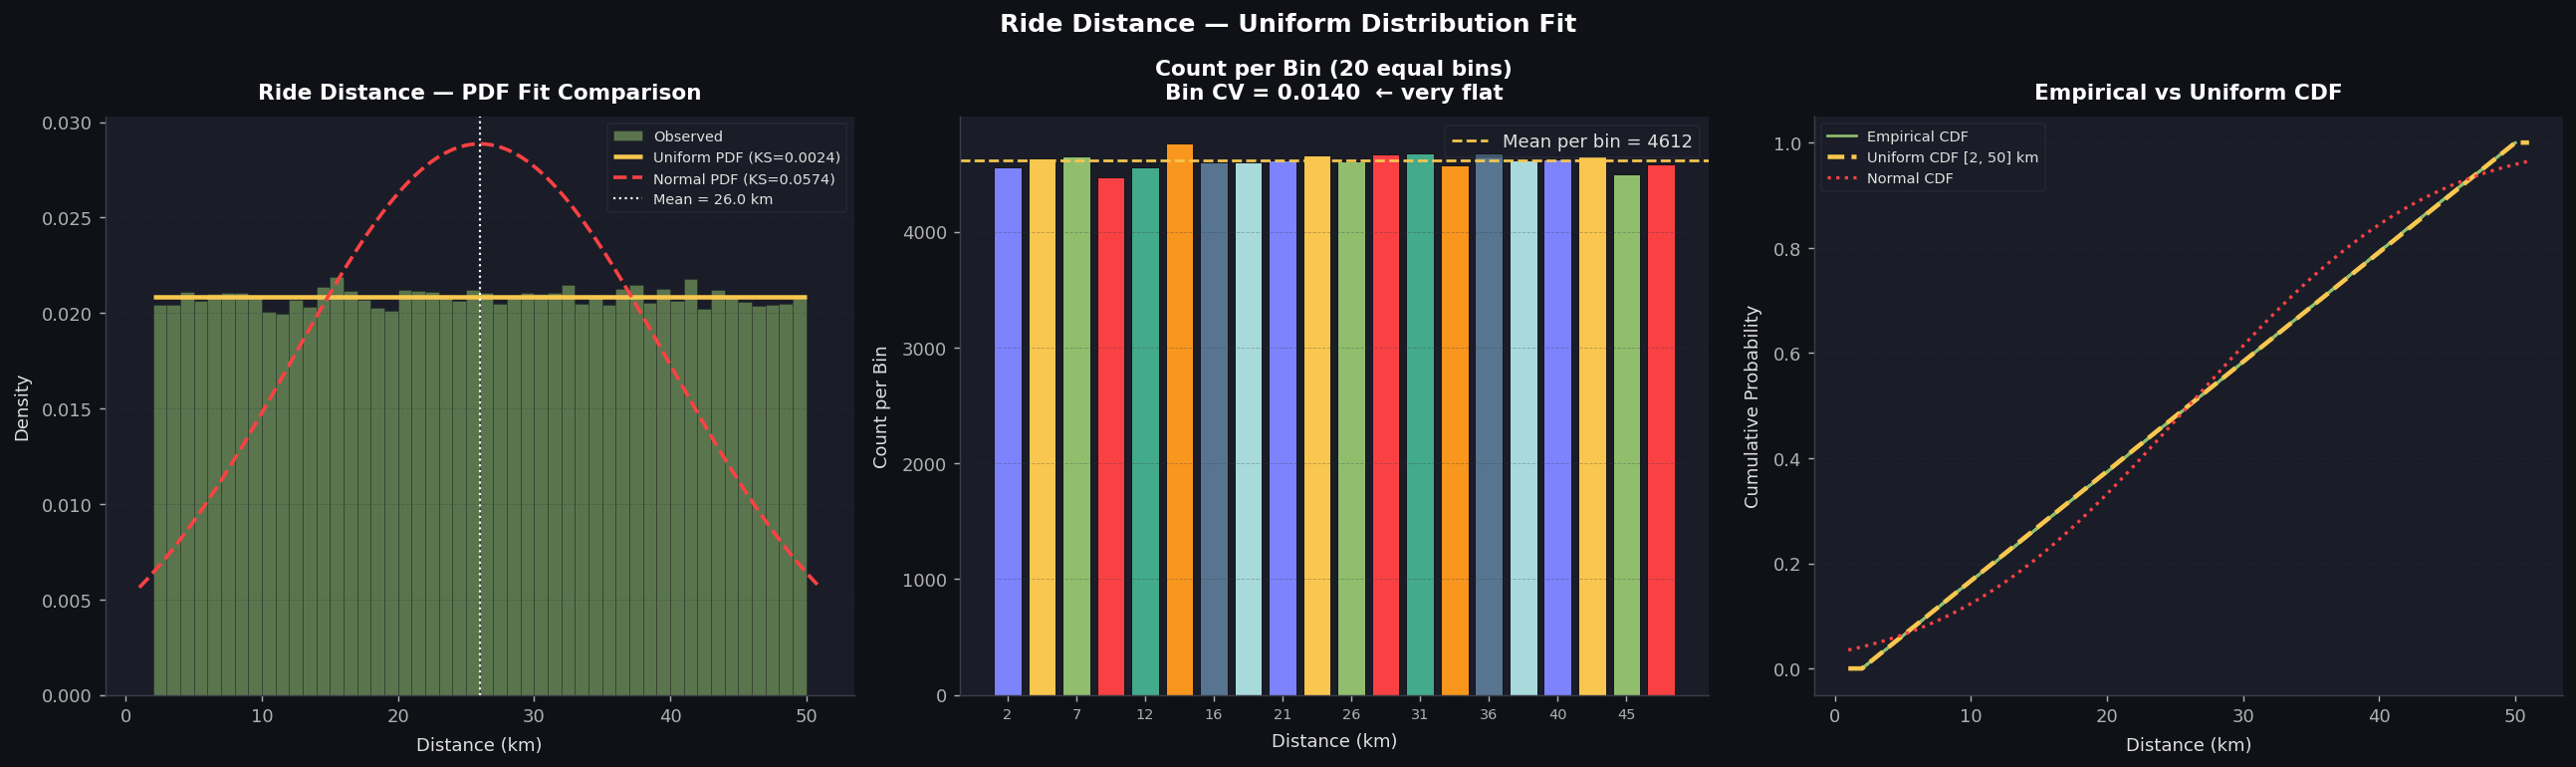

Key insight: The ECDF almost perfectly overlaps the Uniform CDF (a straight diagonal).
Every ride length between 2 km and 50 km is approximately equally likely.

EDA cross-check (cell 9): Distance vs Booking Value R² = 0.001 — no linear relationship.
This independently confirms distance carries no signal for demand or fare prediction.


In [18]:
x_rd = np.linspace(rd.min() - 1, rd.max() + 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Ride Distance — Uniform Distribution Fit",
             fontsize=14, fontweight="bold", color="#ffffff")

# Histogram + Uniform PDF (flat line) vs Normal PDF (bell curve — clearly wrong)
axes[0].hist(rd, bins=48, density=True, color=SUCCESS, alpha=0.55,
             edgecolor="#0f1117", linewidth=0.3, label="Observed")
u_pdf_height = 1.0 / (rd.max() - rd.min())
axes[0].hlines(u_pdf_height, rd.min(), rd.max(), colors=ACCENT2, linewidth=2.5,
               label=f"Uniform PDF (KS={ks_u:.4f})")
axes[0].plot(x_rd, norm.pdf(x_rd, *nm_rd),
             color=DANGER, linewidth=2, linestyle="--", label=f"Normal PDF (KS={ks_nm:.4f})")
axes[0].axvline(rd.mean(), color="white", linestyle=":", linewidth=1.2,
                label=f"Mean = {rd.mean():.1f} km")
style_ax(axes[0], "Ride Distance — PDF Fit Comparison", "Distance (km)", "Density")
axes[0].legend(fontsize=8)

# Histogram with 20 equal bins — nearly flat proves uniform
axes[1].bar(
    range(20),
    hist_counts,
    color=[PALETTE[i % len(PALETTE)] for i in range(20)],
    edgecolor="#0f1117", linewidth=0.5
)
axes[1].axhline(hist_counts.mean(), color=ACCENT2, linestyle="--", linewidth=1.5,
                label=f"Mean per bin = {hist_counts.mean():.0f}")
axes[1].set_xticks(range(0, 20, 2))
axes[1].set_xticklabels([f"{rd.min() + i*2.4:.0f}" for i in range(0, 20, 2)], fontsize=8)
style_ax(axes[1],
         f"Count per Bin (20 equal bins)\nBin CV = {bin_cv:.4f}  ← very flat",
         "Distance (km)", "Count per Bin")
axes[1].legend()

# ECDF vs Uniform CDF (should be nearly diagonal straight line)
x_ecdf = np.sort(rd)
y_ecdf = np.arange(1, len(rd)+1) / len(rd)
axes[2].plot(x_ecdf, y_ecdf, color=SUCCESS, linewidth=1.5, label="Empirical CDF")
axes[2].plot(x_rd, uniform.cdf(x_rd, u_loc, u_scale),
             color=ACCENT2, linewidth=2.5, linestyle="--",
             label=f"Uniform CDF [{rd.min():.0f}, {rd.max():.0f}] km")
axes[2].plot(x_rd, norm.cdf(x_rd, *nm_rd),
             color=DANGER, linewidth=1.8, linestyle=":", label="Normal CDF")
style_ax(axes[2], "Empirical vs Uniform CDF", "Distance (km)", "Cumulative Probability")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

print("Key insight: The ECDF almost perfectly overlaps the Uniform CDF (a straight diagonal).")
print("Every ride length between 2 km and 50 km is approximately equally likely.")
print()
print("EDA cross-check (cell 9): Distance vs Booking Value R² = 0.001 — no linear relationship.")
print("This independently confirms distance carries no signal for demand or fare prediction.")

---
## 4. Booking Outcome — Multinomial Distribution

Each booking independently results in one of five possible outcomes. This is modeled as a **Multinomial distribution** where we estimate the probability of each outcome category from the data.

We also run a **Chi-Square test of independence** to check whether these probabilities change across vehicle types — the result (p = 0.26) confirms they do **not**.

In [19]:
status_probs = df["Booking Status"].value_counts(normalize=True).sort_values(ascending=False)
status_count = df["Booking Status"].value_counts().sort_values(ascending=False)

# Chi-square test: does vehicle type affect booking outcome?
ct = pd.crosstab(df["Vehicle Type"], df["Booking Status"])
chi2, p_chi, dof, expected = chi2_contingency(ct)

# Completion rate per vehicle type
comp_by_veh = df.groupby("Vehicle Type")["Booking Status"].apply(
    lambda x: (x == "Completed").sum() / len(x) * 100
).sort_values(ascending=False)

print("Booking Outcome — Multinomial Distribution")
print("-" * 55)
print(f"  Total bookings    : {len(df):,}")
print(f"  Number of outcomes: {df['Booking Status'].nunique()}")
print()
for status, prob in status_probs.items():
    count = status_count[status]
    print(f"  {status:<30} : {prob*100:.4f}%  ({count:,})")
print()
cancel_rate = (status_probs.get("Cancelled by Driver",0) + status_probs.get("Cancelled by Customer",0)) * 100
unserved    = (status_probs.get("No Driver Found",0)     + status_probs.get("Incomplete",0)) * 100
print(f"  Combined cancellation rate      : {cancel_rate:.2f}%")
print(f"  Demand not served               : {unserved:.2f}%")
print(f"  Effective service rate          : {status_probs.get('Completed',0)*100:.2f}%")
print()
print(f"  Chi-Square Test (Vehicle Type vs Booking Status):")
print(f"    Chi2 = {chi2:.2f},  df = {dof},  p = {p_chi:.4f}")
print(f"    Result: {'Cannot reject independence — vehicle type does NOT affect outcome' if p_chi > 0.05 else 'Significant association found'}")
print()
print("  Completion rate by vehicle type:")
for veh, rate in comp_by_veh.items():
    print(f"    {veh:<16} : {rate:.2f}%")
print(f"  Range: {comp_by_veh.max()-comp_by_veh.min():.2f} percentage points — effectively identical")

Booking Outcome — Multinomial Distribution
-------------------------------------------------------
  Total bookings    : 148,767
  Number of outcomes: 5

  Completed                      : 62.0084%  (92,248)
  Cancelled by Driver            : 18.0074%  (26,789)
  Cancelled by Customer          : 6.9921%  (10,402)
  No Driver Found                : 6.9915%  (10,401)
  Incomplete                     : 6.0007%  (8,927)

  Combined cancellation rate      : 25.00%
  Demand not served               : 12.99%
  Effective service rate          : 62.01%

  Chi-Square Test (Vehicle Type vs Booking Status):
    Chi2 = 28.00,  df = 24,  p = 0.2602
    Result: Cannot reject independence — vehicle type does NOT affect outcome

  Completion rate by vehicle type:
    Uber XL          : 62.53%
    Bike             : 62.38%
    Go Mini          : 62.27%
    Premier Sedan    : 62.16%
    eBike            : 61.96%
    Auto             : 61.87%
    Go Sedan         : 61.45%
  Range: 1.08 percentage points —

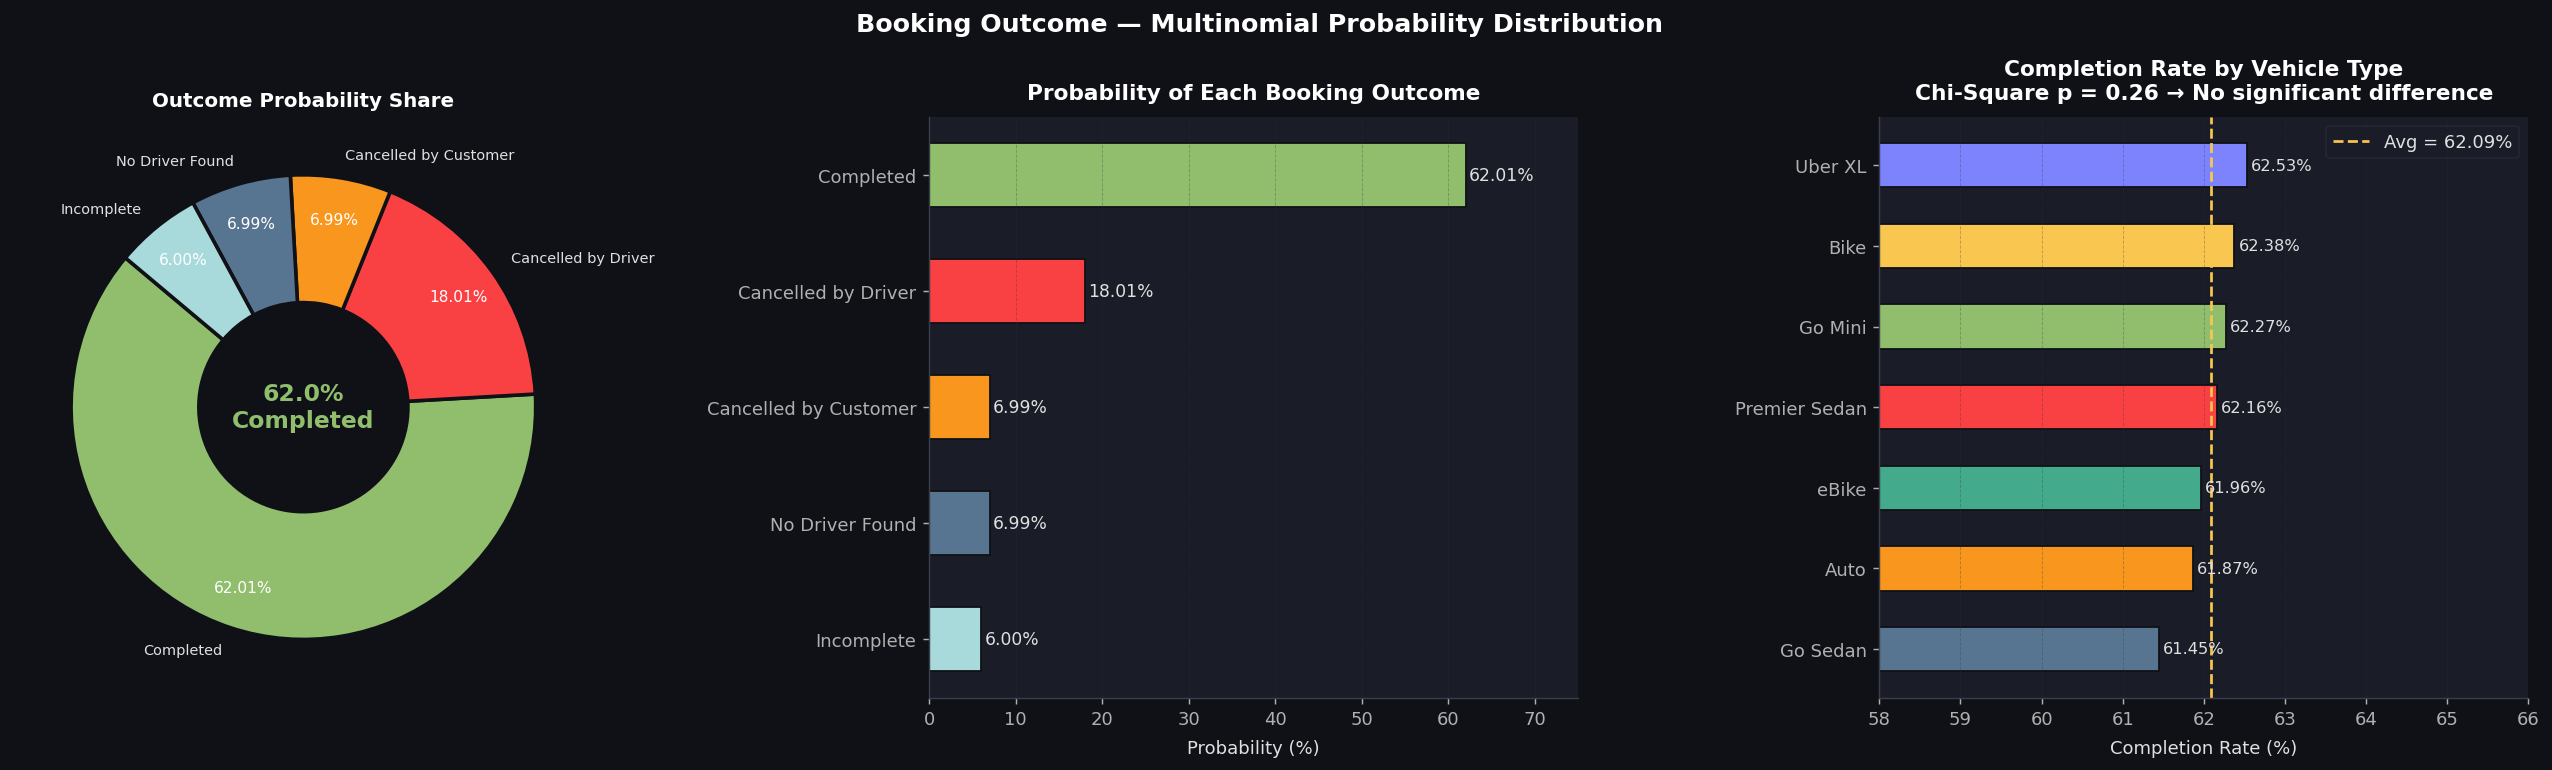

In [20]:
status_colors = [SUCCESS, DANGER, "#f8961e", "#577590", "#a8dadc"]
statuses      = status_probs.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Booking Outcome — Multinomial Probability Distribution",
             fontsize=14, fontweight="bold", color="#ffffff")

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    status_probs.values,
    labels=statuses,
    colors=status_colors,
    autopct="%1.2f%%",
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor="#0f1117", linewidth=2)
)
for at in autotexts: at.set_fontsize(8.5); at.set_color("white")
for t in texts:      t.set_color("#e0e0e0"); t.set_fontsize(8)
axes[0].add_artist(plt.Circle((0,0), 0.45, fc="#0f1117"))
axes[0].text(0, 0, f"{status_probs.values[0]*100:.1f}%\nCompleted",
             ha="center", va="center", fontsize=13, fontweight="bold", color=SUCCESS)
axes[0].set_title("Outcome Probability Share", color="#ffffff", fontsize=11, fontweight="bold")

# Probability bar chart with exact values
bars = axes[1].barh(status_probs.index[::-1], status_probs.values[::-1] * 100,
                    color=status_colors[::-1], edgecolor="#0f1117", height=0.55)
for bar, val in zip(bars, status_probs.values[::-1]):
    axes[1].text(val * 100 + 0.4, bar.get_y() + bar.get_height()/2,
                 f"{val*100:.2f}%", va="center", fontsize=9.5, color="#e0e0e0")
style_ax(axes[1], "Probability of Each Booking Outcome", "Probability (%)", "", grid="x")
axes[1].set_xlim(0, 75)

# Completion rate per vehicle — shows uniformity (chi-square result visually)
bar_cols = [PALETTE[i % len(PALETTE)] for i in range(len(comp_by_veh))]
bars2 = axes[2].barh(comp_by_veh.index[::-1], comp_by_veh.values[::-1],
                     color=bar_cols[::-1], edgecolor="#0f1117", height=0.55)
for bar, val in zip(bars2, comp_by_veh.values[::-1]):
    axes[2].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}%", va="center", fontsize=9, color="#e0e0e0")
axes[2].axvline(comp_by_veh.mean(), color=ACCENT2, linestyle="--", linewidth=1.5,
                label=f"Avg = {comp_by_veh.mean():.2f}%")
style_ax(axes[2],
         f"Completion Rate by Vehicle Type\nChi-Square p = {p_chi:.2f} → No significant difference",
         "Completion Rate (%)", "", grid="x")
axes[2].set_xlim(58, 66)
axes[2].legend()

fig.tight_layout()
plt.show()

---
## Summary of Findings

| Variable | Best-fit Distribution | Key Parameters | Key Insight |
|---|---|---|---|
| Hourly ride counts | Poisson (overdispersed) | λ = 17.07, Dispersion = 6.11 | Rate varies by hour; peak at 18:00 |
| Booking value | Log-Normal | μ = ₹492, Median = ₹414, σ = ₹332, Skew = 0.94 | Right-skewed; premium-ride tail |
| Ride distance | **Uniform** | a = 2 km, b = 50 km, KS = 0.0024 | Every distance equally likely |
| Booking outcome | Multinomial | P(Completed) = 62.01%, P(Driver cancel) = 18.01% | Uniform across vehicle types (p=0.26) |